In [1]:
print("Hellow World")

Hellow World


In [42]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor


In [4]:
df = pd.read_csv("TSLA_stock_data.csv")

In [4]:
df.head(10)

,date,open,high,low,close,volume
0,2025-11-03,455.99,474.0700,453.80,468.37,84595244
1,2025-11-04,454.46,460.2200,443.60,444.26,87756644
2,2025-11-05,452.05,466.3299,440.71,462.07,84911911
3,2025-11-06,461.96,467.4500,435.09,445.91,109622907
4,2025-11-07,437.92,439.3600,421.88,429.52,103471495
5,2025-11-10,439.60,449.6715,433.36,445.23,76515907
6,2025-11-11,439.40,442.4900,432.36,439.62,60533237
7,2025-11-12,442.15,442.3290,426.56,430.60,58513520
8,2025-11-13,423.13,424.5000,396.34,401.99,118948032
9,2025-11-14,386.30,412.1900,382.78,404.35,105506682


In [5]:
df.isnull().sum()

date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    100 non-null    str    
 1   open    100 non-null    float64
 2   high    100 non-null    float64
 3   low     100 non-null    float64
 4   close   100 non-null    float64
 5   volume  100 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 4.8 KB


In [5]:
df['date']=pd.to_datetime(df['date'])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    100 non-null    datetime64[us]
 1   open    100 non-null    float64       
 2   high    100 non-null    float64       
 3   low     100 non-null    float64       
 4   close   100 non-null    float64       
 5   volume  100 non-null    int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 4.8 KB


In [6]:
#feature engineering

df['daily_return'] = (df['close'] - df['open']) / df['open']
df['price_range'] = df['high'] - df['low']
df['vol_ma_5'] = df['volume'].rolling(window=5).mean()

In [10]:
df.head(10)

,date,open,high,low,close,volume,daily_return,price_range,vol_ma_5
0,2025-11-03,455.99,474.0700,453.80,468.37,84595244,0.027150,20.2700,NaN
1,2025-11-04,454.46,460.2200,443.60,444.26,87756644,-0.022444,16.6200,NaN
2,2025-11-05,452.05,466.3299,440.71,462.07,84911911,0.022166,25.6199,NaN
3,2025-11-06,461.96,467.4500,435.09,445.91,109622907,-0.034743,32.3600,NaN
4,2025-11-07,437.92,439.3600,421.88,429.52,103471495,-0.019182,17.4800,94071640.2
5,2025-11-10,439.60,449.6715,433.36,445.23,76515907,0.012807,16.3115,92455772.8
6,2025-11-11,439.40,442.4900,432.36,439.62,60533237,0.000501,10.1300,87011091.4
7,2025-11-12,442.15,442.3290,426.56,430.60,58513520,-0.026122,15.7690,81731413.2
8,2025-11-13,423.13,424.5000,396.34,401.99,118948032,-0.049961,28.1600,83596438.2
9,2025-11-14,386.30,412.1900,382.78,404.35,105506682,0.046725,29.4100,84003475.6


In [7]:
# Moving averages
df['ma_5'] = df['close'].rolling(window=5).mean()
df['ma_10'] = df['close'].rolling(window=10).mean()

In [12]:
df.head(10)

,date,open,high,low,close,volume,daily_return,price_range,vol_ma_5,ma_5,ma_10
0,2025-11-03,455.99,474.0700,453.80,468.37,84595244,0.027150,20.2700,NaN,NaN,NaN
1,2025-11-04,454.46,460.2200,443.60,444.26,87756644,-0.022444,16.6200,NaN,NaN,NaN
2,2025-11-05,452.05,466.3299,440.71,462.07,84911911,0.022166,25.6199,NaN,NaN,NaN
3,2025-11-06,461.96,467.4500,435.09,445.91,109622907,-0.034743,32.3600,NaN,NaN,NaN
4,2025-11-07,437.92,439.3600,421.88,429.52,103471495,-0.019182,17.4800,94071640.2,450.026,NaN
5,2025-11-10,439.60,449.6715,433.36,445.23,76515907,0.012807,16.3115,92455772.8,445.398,NaN
6,2025-11-11,439.40,442.4900,432.36,439.62,60533237,0.000501,10.1300,87011091.4,444.470,NaN
7,2025-11-12,442.15,442.3290,426.56,430.60,58513520,-0.026122,15.7690,81731413.2,438.176,NaN
8,2025-11-13,423.13,424.5000,396.34,401.99,118948032,-0.049961,28.1600,83596438.2,429.392,NaN
9,2025-11-14,386.30,412.1900,382.78,404.35,105506682,0.046725,29.4100,84003475.6,424.358,437.192


In [9]:
df = df.dropna()

In [14]:
df.head(10)

,date,open,high,low,close,volume,daily_return,price_range,vol_ma_5,ma_5,ma_10
9,2025-11-14,386.30,412.19,382.78,404.35,105506682,0.046725,29.41,84003475.6,424.358,437.192
10,2025-11-17,398.74,423.96,398.74,408.92,102214259,0.025530,25.22,89143146.0,417.096,431.247
11,2025-11-18,405.38,408.90,393.71,401.25,80688637,-0.010188,15.19,93174226.0,409.422,426.946
12,2025-11-19,406.18,411.78,398.50,403.99,72047704,-0.005392,13.28,95881062.8,404.100,421.138
13,2025-11-20,414.63,428.94,394.74,395.23,113548827,-0.046789,34.20,94801221.8,402.748,416.070
14,2025-11-21,402.32,402.80,383.76,391.09,100460633,-0.027913,19.04,93792012.0,400.096,412.227
15,2025-11-24,402.17,421.72,401.09,417.78,96806374,0.038814,20.63,92710435.0,401.868,409.482
16,2025-11-25,414.42,420.48,405.95,419.40,71915624,0.012017,14.53,90955832.4,405.498,407.460
17,2025-11-26,423.95,426.94,416.89,426.58,63462996,0.006204,10.05,89238890.8,410.016,407.058
18,2025-11-28,426.59,432.93,426.20,430.17,36252861,0.008392,6.73,73779697.6,417.004,409.876


In [8]:
df['target'] = df['close'].shift(-1)

In [10]:
features = ['open', 'high', 'low', 'close', 'volume','daily_return', 'price_range', 'ma_5', 'ma_10', 'vol_ma_5']
X = df[features]
y = df['target']

In [11]:
#data preparing to trian and test 

split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [12]:
#using Linear Regression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
y_pred = model.predict(X_test)

In [14]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 6.964665833285222


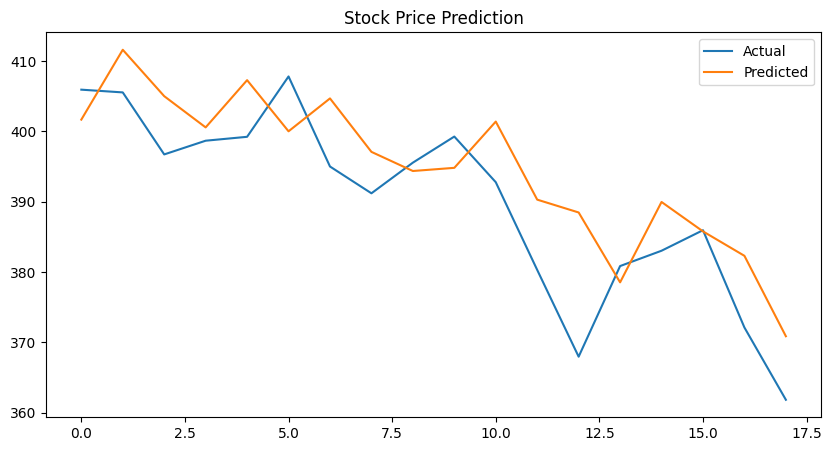

In [15]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Stock Price Prediction")
plt.show()

In [ ]:
# from lightgbm import LGBMRegressor

# lgb_model = LGBMRegressor(
#     n_estimators=200,
#     learning_rate=0.05,
#     max_depth=-1,
#     num_leaves=31,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42
# )

# lgb_model.fit(X_train, y_train)

# y_pred_lgb = lgb_model.predict(X_test)

In [16]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [17]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
print("XGBoost MAE:", mae_xgb)


XGBoost MAE: 25.326971706814238


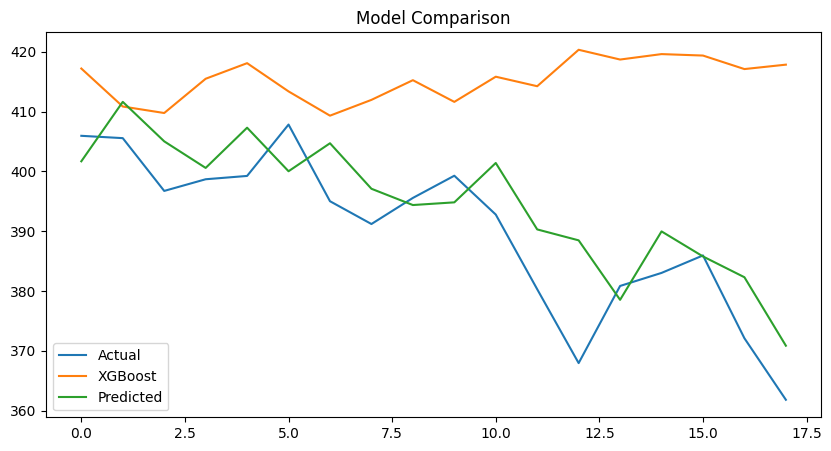

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_xgb, label='XGBoost')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Model Comparison")
plt.show()

In [19]:
# lag features
df['lag_1'] = df['close'].shift(1)
df['lag_2'] = df['close'].shift(2)
df['lag_3'] = df['close'].shift(3)

df = df.dropna()

In [20]:
features = ['open','high','low','close','volume','daily_return','price_range','ma_5','ma_10','vol_ma_5','lag_1','lag_2','lag_3']
X = df[features]
y = df['target']

In [21]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [25]:
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=8,
    min_child_weight=1,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [26]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
print("XGBoost MAE:", mae_xgb)


XGBoost MAE: 26.756838921440973


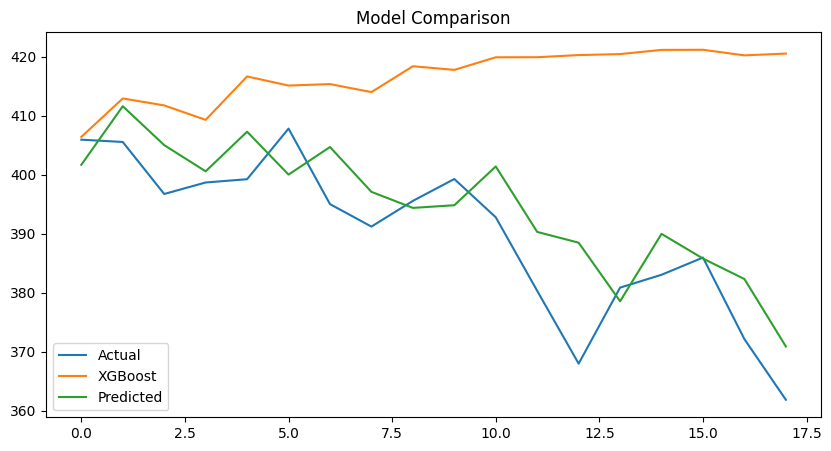

In [27]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_xgb, label='XGBoost')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Model Comparison")
plt.show()

In [ ]:
#altering


In [28]:
df = pd.read_csv("TSLA_stock_data.csv")

In [ ]:
df['daily_return']=(df['close'] - df['open']) / df['open']
df['price_range']=df['high'] - df['low']
df['vol_ma_5']=df['volume'].rolling(5).mean()
df['ma_5']=df['close'].rolling(5).mean()
df['ma_10']=df['close'].rolling(10).mean()

In [30]:
df['close_lag1']=df['close'].shift(1)
df['close_lag2']=df['close'].shift(2)
df['return_lag1']=df['daily_return'].shift(1)
df['high_lag1']=df['high'].shift(1)
df['low_lag1']=df['low'].shift(1)

In [31]:
df['target'] = df['close'].shift(-1)
df = df.dropna()

In [32]:
features = ['open', 'high', 'low', 'volume','daily_return', 'price_range','ma_5', 'ma_10', 'vol_ma_5','close_lag1', 'close_lag2','return_lag1', 'high_lag1', 'low_lag1']
X = df[features]
y = df['target']

In [33]:
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [34]:
xgb_model = XGBRegressor(
    n_estimators     = 200,
    learning_rate    = 0.05,
    max_depth        = 3,        # shallow tree — avoids overfitting on small data
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,      # L1 regularization
    reg_lambda       = 1.0,      # L2 regularization
    random_state     = 42,
    verbosity        = 0
)

In [35]:
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

In [40]:
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 26.94
R²  : -4.7528


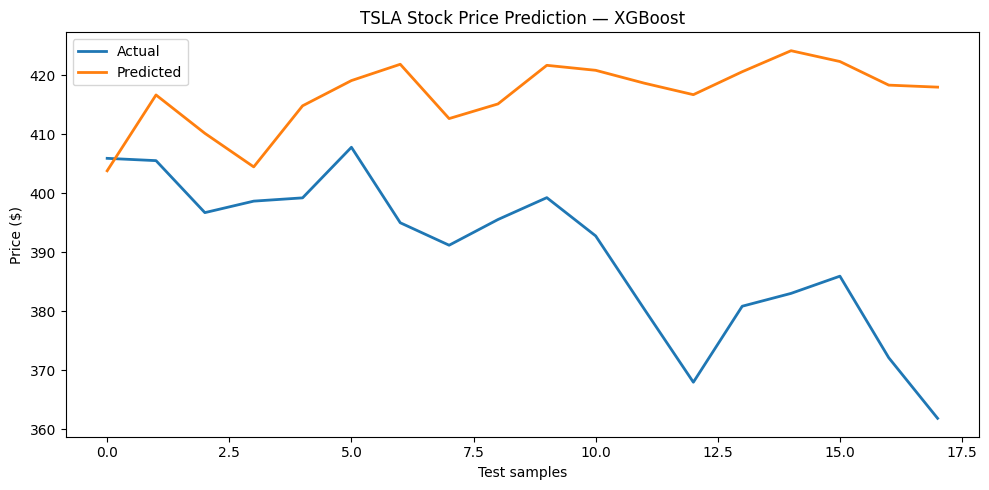

In [41]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values,label='Actual', linewidth=2)
plt.plot(y_pred,label='Predicted', linewidth=2)
plt.legend()
plt.title("TSLA Stock Price Prediction — XGBoost")
plt.xlabel("Test samples")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.show()

In [ ]:
model = LGBMRegressor(
    n_estimators     = 200,
    learning_rate    = 0.05,
    max_depth        = -1,       
    num_leaves       = 15,       
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    verbose          = -1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [44]:
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 17.89
R²  : -1.6836


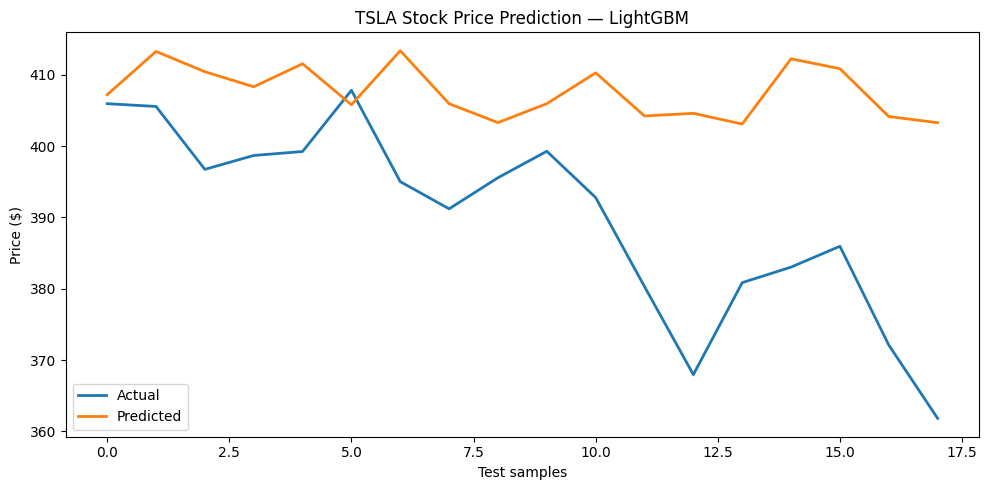

In [47]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values,label='Actual', linewidth=2)
plt.plot(y_pred,label='Predicted', linewidth=2)
plt.legend()
plt.title("TSLA Stock Price Prediction — LightGBM")
plt.xlabel("Test samples")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.show()

In [ ]:
#another Alternate

In [49]:
import yfinance as yf
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt


In [ ]:
df = yf.download("TSLA", start="2019-01-01", end="2024-12-31", auto_adjust=True)
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
df.columns = ['open', 'high', 'low', 'close', 'volume']
df = df.sort_index().reset_index(drop=True)
print(f"Total rows: {len(df)}")  

[*********************100%***********************]  1 of 1 completed

Total rows: 1509


In [51]:
df.head(10)

,open,high,low,close,volume
0,20.406668,21.008667,19.920000,20.674667,174879000
1,20.466667,20.626667,19.825333,20.024000,104478000
2,20.400000,21.200001,20.181999,21.179333,110911500
3,21.448000,22.449333,21.183332,22.330667,113268000
4,22.797333,22.934000,21.801332,22.356667,105127500
5,22.366667,22.900000,22.098000,22.568666,81493500
6,22.293333,23.025999,22.119333,22.997999,90846000
7,22.806000,23.227333,22.584667,23.150667,75586500
8,22.825333,22.833332,22.266666,22.293333,78709500
9,22.333332,23.253332,22.299999,22.962000,90849000


In [ ]:
#Feature engineering 
df['daily_return'] = (df['close'] - df['open']) / df['open']
df['price_range']  = df['high'] - df['low']
df['vol_ma_5']     = df['volume'].rolling(5).mean()
df['ma_5']         = df['close'].rolling(5).mean()
df['ma_10']        = df['close'].rolling(10).mean()
df['ma_20']        = df['close'].rolling(20).mean()
df['close_lag1']   = df['close'].shift(1)
df['close_lag2']   = df['close'].shift(2)
df['close_lag3']   = df['close'].shift(3)
df['return_lag1']  = df['daily_return'].shift(1)
df['volatility_5'] = df['daily_return'].rolling(5).std()
df['target']       = df['close'].shift(-1)
df = df.dropna()
print(f"After dropna: {len(df)} rows")

After dropna: 1489 rows


In [53]:
features = [
    'open', 'high', 'low', 'volume',
    'daily_return', 'price_range',
    'ma_5', 'ma_10', 'ma_20', 'vol_ma_5',
    'close_lag1', 'close_lag2', 'close_lag3',
    'return_lag1', 'volatility_5'
]

X, y = df[features], df['target']
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [64]:
# LightGBM 
model = LGBMRegressor(
    n_estimators=500, learning_rate=0.03,
    num_leaves=31, subsample=0.8,
    colsample_bytree=0.8, random_state=42, verbose=-1
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [65]:
print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R²  : {r2_score(y_test, y_pred):.4f}")


MAE : 9.46
R²  : 0.9328


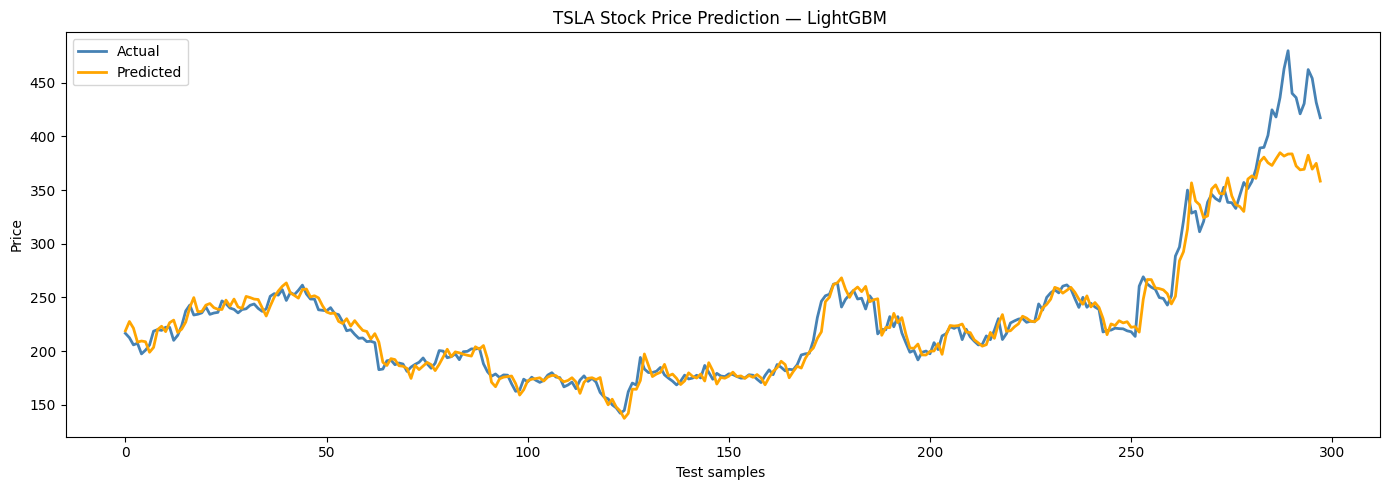

In [66]:
#plot
plt.figure(figsize=(14, 5))
plt.plot(y_test.values, label='Actual',color='steelblue',linewidth=2)
plt.plot(y_pred,label='Predicted', color='orange',linewidth=2)
plt.legend()
plt.title("TSLA Stock Price Prediction — LightGBM ")
plt.xlabel("Test samples ")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

In [58]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500, learning_rate=0.03,
    max_depth=4, subsample=0.8,
    colsample_bytree=0.8, random_state=42, verbosity=0
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [59]:
print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R²  : {r2_score(y_test, y_pred):.4f}")

MAE : 9.04
R²  : 0.9344


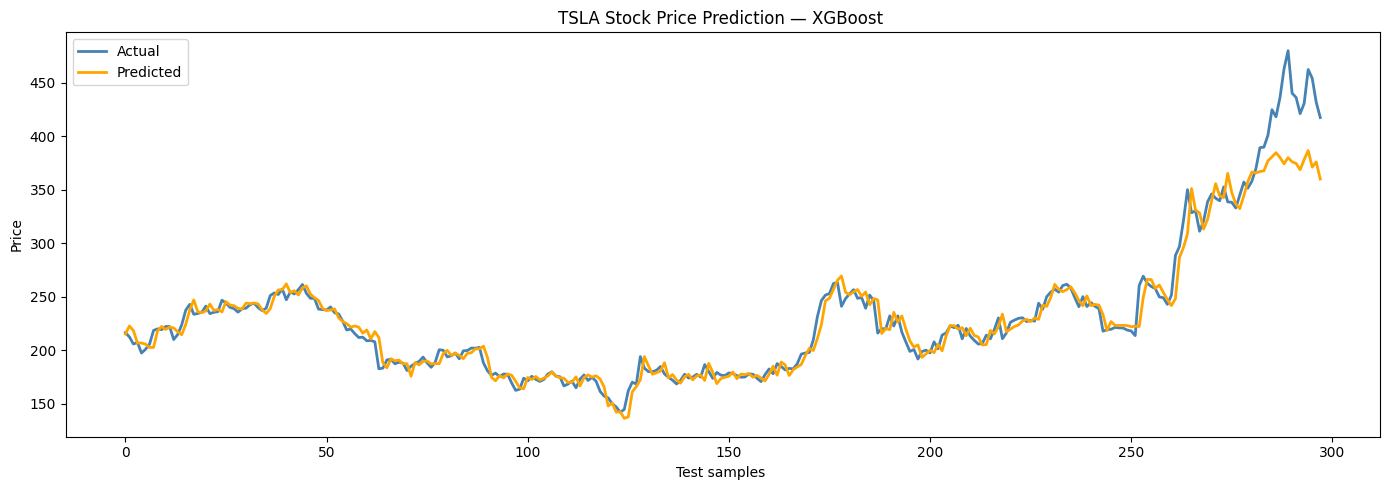

In [62]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.values,label='Actual',color='steelblue',linewidth=2)
plt.plot(y_pred,label='Predicted',color='orange',linewidth=2)
plt.legend()
plt.title("TSLA Stock Price Prediction — XGBoost ")
plt.xlabel("Test samples ")
plt.ylabel("Price")
plt.tight_layout()
plt.show()